# Mutations and Clones

In [1]:
import itertools
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy.stats import ttest_ind, gaussian_kde
from scipy.spatial import KDTree

In [2]:
sc.settings.verbosity = 3             
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.10.4 anndata==0.11.1 umap==0.5.7 numpy==2.0.2 scipy==1.14.1 pandas==2.2.3 scikit-learn==1.6.0 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [3]:
gois = ['LamC', 'Prosalpha3']

In [4]:
run_labels = [
    'TX45 ctrl',
    'TX45 LamC',
    'TX45 Prosalpha3',
    'TX46 ctrl',
    'TX46 LamC',
    'TX46 Prosalpha3'
]

# Load Data

In [5]:
bc_adata = sc.read('data/scptseq_adata.h5ad')

In [6]:
target_reads = pd.read_excel('data/target_reads.xlsx', sheet_name=None, index_col=0)

# Celltypes, expression, and mutation capture

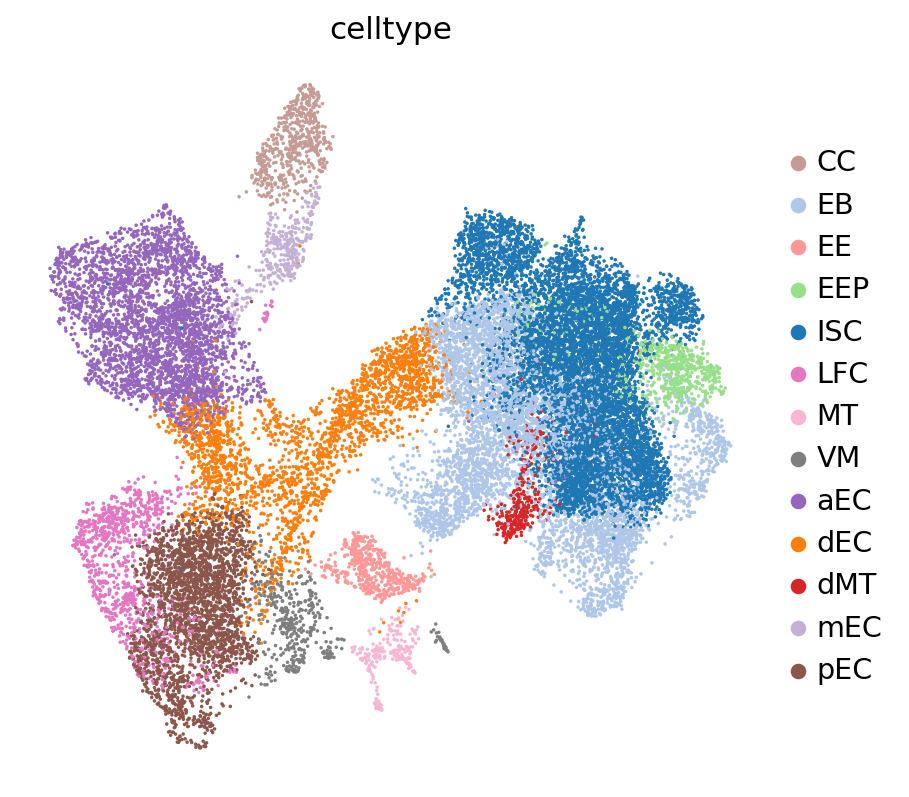

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(bc_adata, color='celltype', size=10, frameon=False, ax=ax)

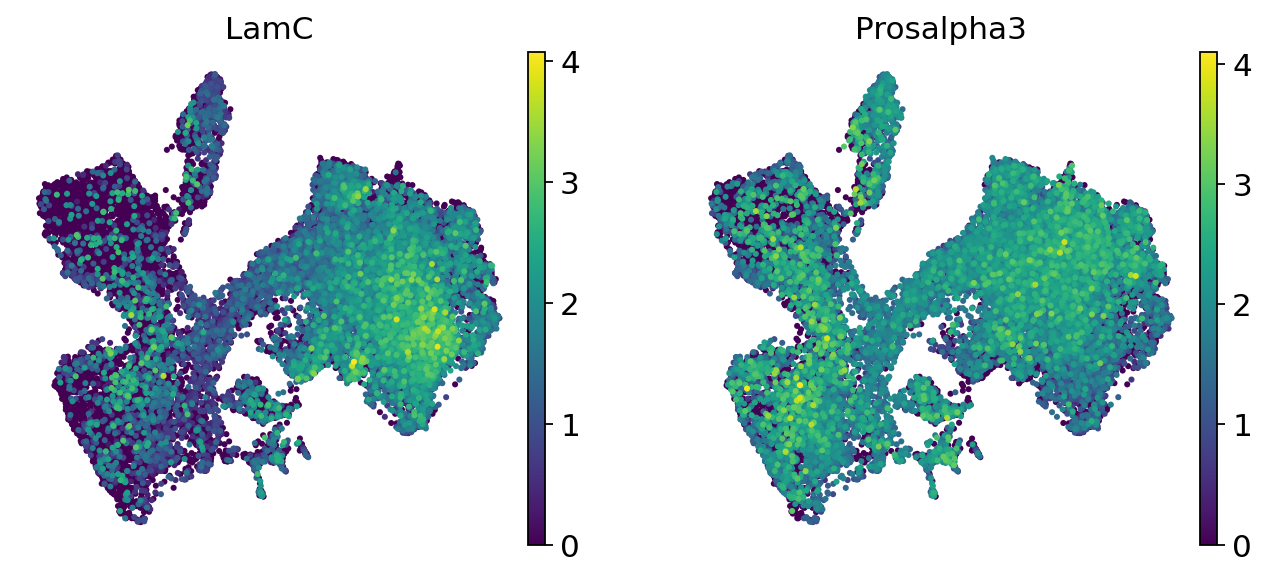

In [8]:
genes = gois
genes = [gene for gene in genes if gene in bc_adata.raw.var.index]
fig = sc.pl.umap(bc_adata, color=genes, legend_loc='on data', frameon=False, size=30, return_fig=True)


............................................................................................................

/scratch/jobs/50207895/ipykernel_2075343/1243107565.py:15: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tmp.obs['ball_avg_expression'] = avg_expression


................................................................

/scratch/jobs/50207895/ipykernel_2075343/1243107565.py:15: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tmp.obs['ball_avg_expression'] = avg_expression


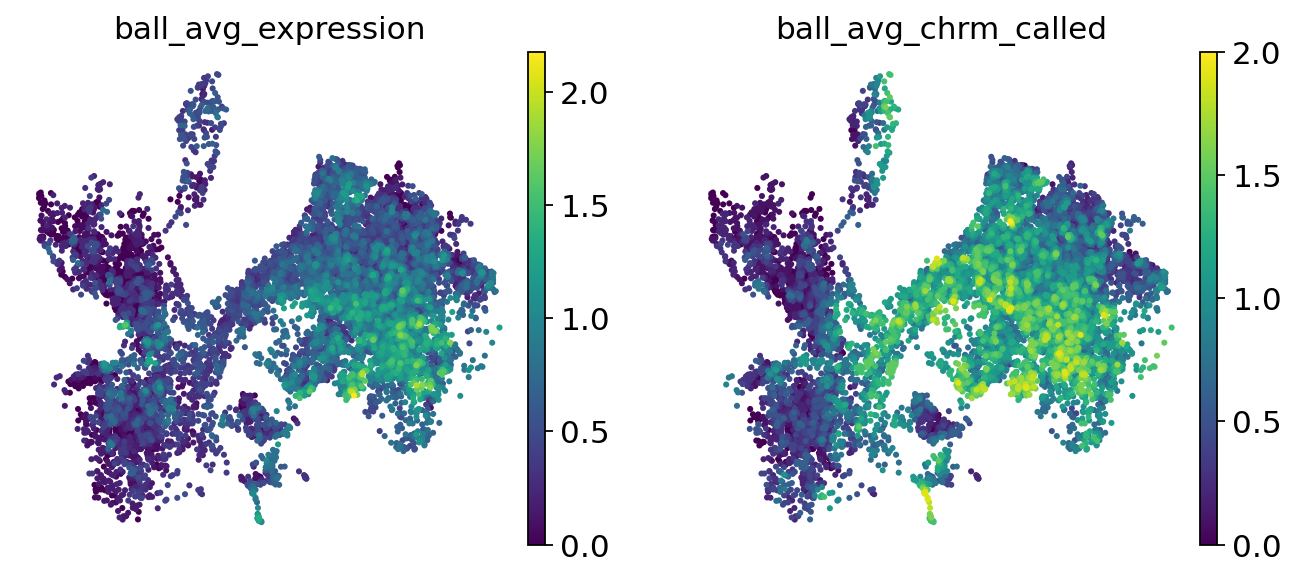

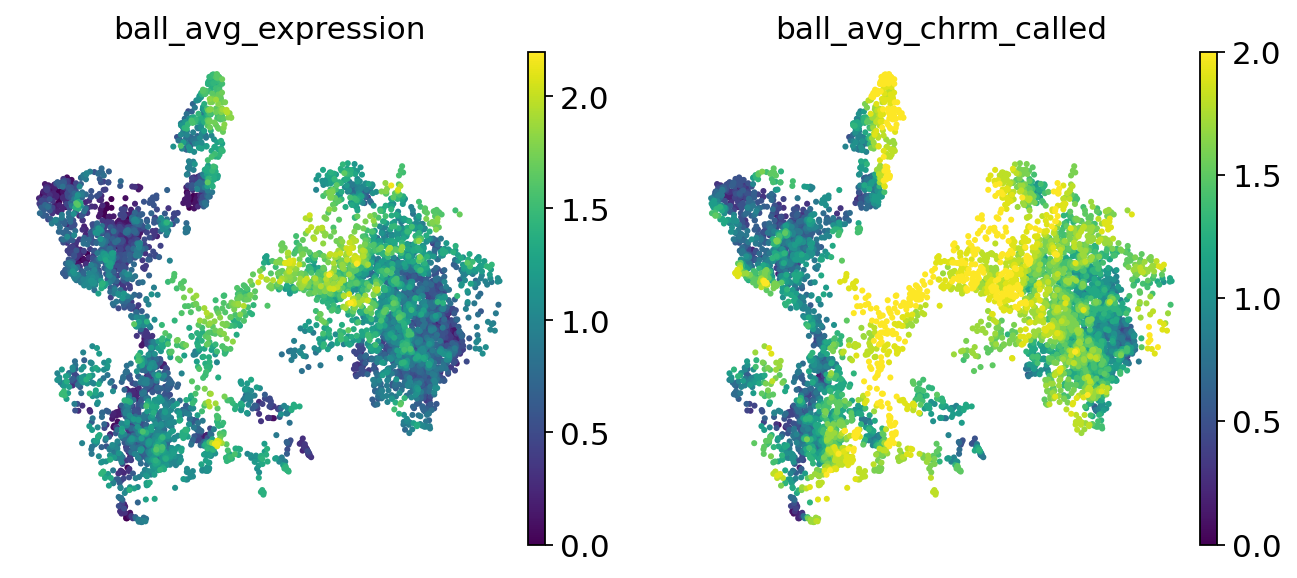

In [9]:
for goi in gois:
    tmp = bc_adata[bc_adata.obs.perturbation == goi]
    tmp_kdtree = KDTree(tmp.obsm['X_umap'])
    avg_expression, n_chrm_w_mut = [], []
    for i in range(len(tmp)):
        if i % 100 == 0:
            print('.', end='')
        bc = tmp.obs.index[i]
        dists, idxs = tmp_kdtree.query(tmp.obsm['X_umap'][i], 10) #11)
        new_tmp = tmp[idxs]
        avg_expression.append(new_tmp.raw[:, goi].X.mean())
        n_chrm_w_mut.append(sum(0 if s == '' else 1 if s == 'uncalled' else 2 for s in new_tmp.obs.het_hom_with_uncalled_status)/10)
    max_idx = max(range(len(n_chrm_w_mut)), key=n_chrm_w_mut.__getitem__)
    n_chrm_w_mut[max_idx] = 2
    tmp.obs['ball_avg_expression'] = avg_expression
    tmp.obs['ball_avg_chrm_called'] = n_chrm_w_mut
    fig = sc.pl.umap(tmp, color=['ball_avg_expression', 'ball_avg_chrm_called'], frameon=False, size=30, return_fig=True)


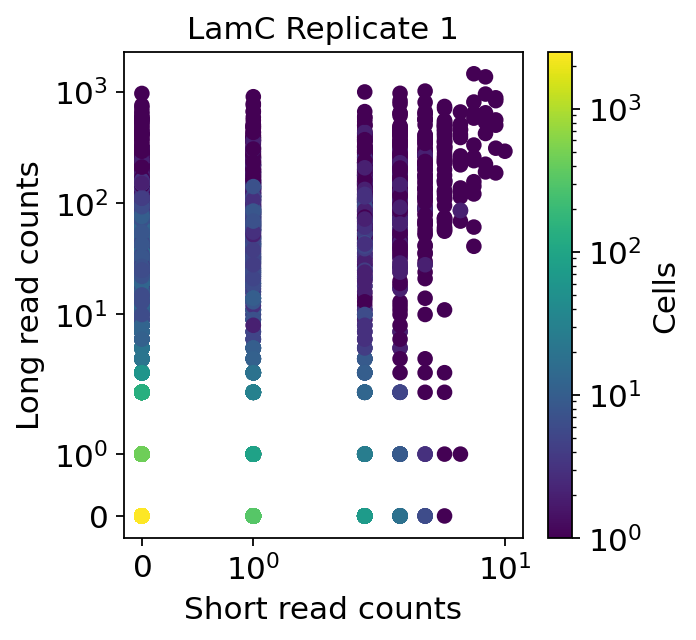

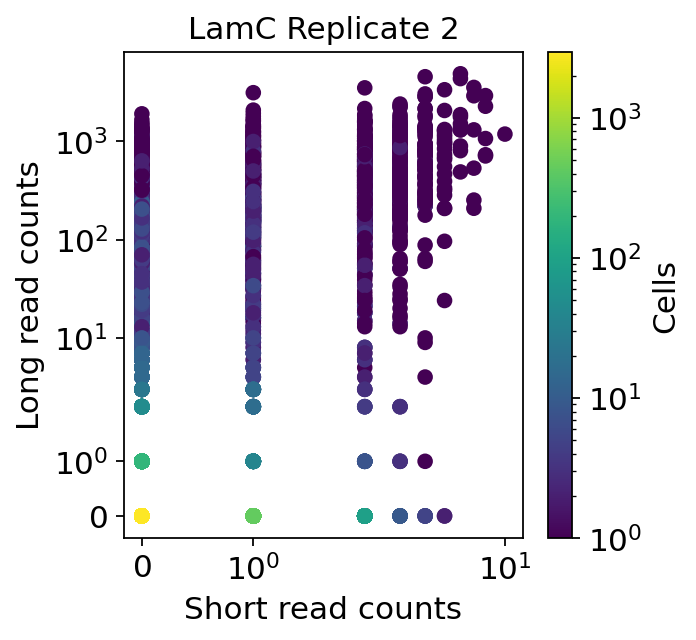

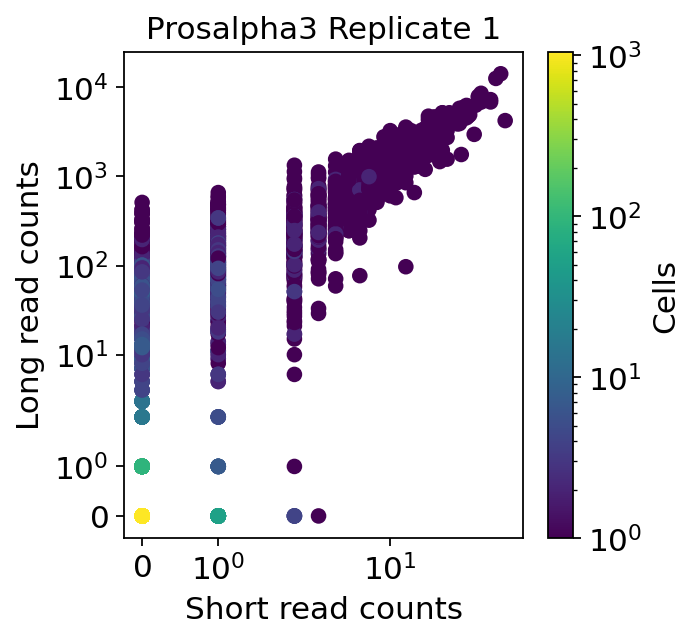

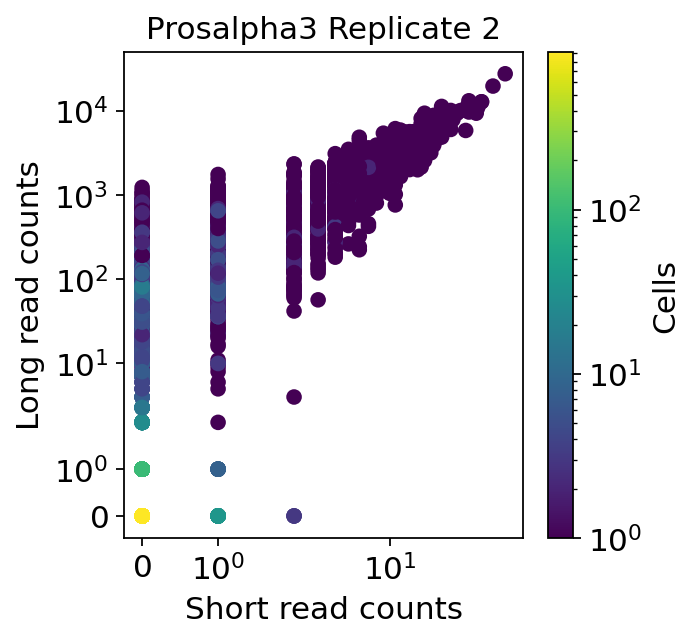

In [10]:
for run, df in sorted(target_reads.items()):
    short_long_n_reads = [(sn, ln) for sn, ln in zip(df.short_reads, df.long_reads)]
    cntr = Counter(short_long_n_reads)
    c = [cntr[tup] for tup in short_long_n_reads]
    fig, ax = plt.subplots()
    v = ax.scatter(df.short_reads, df.long_reads, c=c, norm=matplotlib.colors.LogNorm())
    ax.set_xlabel('Short read counts')
    ax.set_ylabel('Long read counts')
    goi = 'Prosalpha3' if run.startswith('P3') else 'LamC'
    rep = run[-1]
    ax.set_title(f'{goi} Replicate {rep}')
    ax.set_xscale('symlog')
    ax.set_yscale('symlog')
    ax.grid(False)
    cbar = plt.colorbar(v)
    cbar.set_label('Cells')

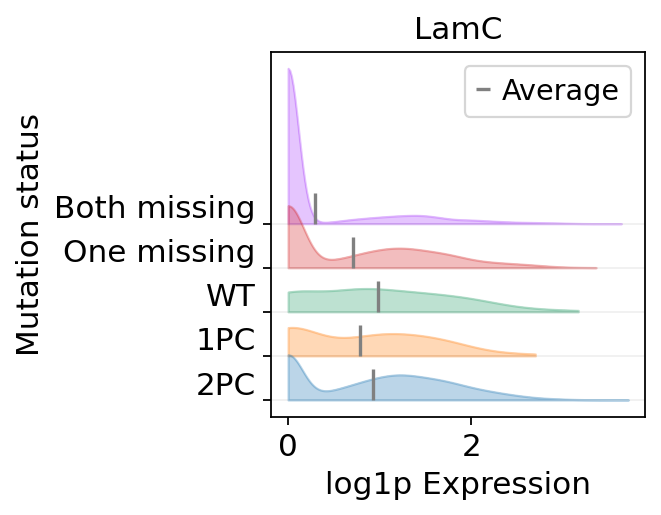

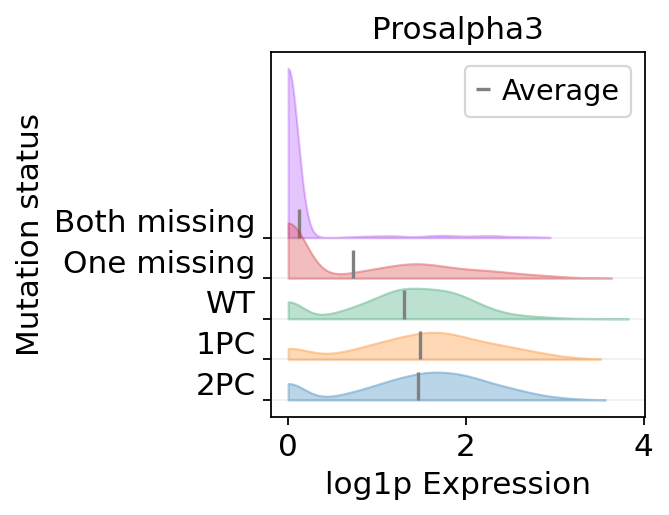

In [11]:
h=0.8
for goi in gois:
    fig, ax = plt.subplots(figsize=(3, 3))
    bottoms = []
    statuses = ['hom', 'het', 'wt', 'uncalled', '']
    for i, status in enumerate(statuses):
        vals = bc_adata[np.logical_and(bc_adata.obs.perturbation == goi, bc_adata.obs.het_hom_with_uncalled_status == status)].raw[:, goi].X
        max_val = vals.max()
        vals = vals.todense().transpose().tolist()[0]
        kde = gaussian_kde(vals)
        avg_val = np.mean(vals)
        bottom = h*i
        bottoms.append(bottom)
        x = np.linspace(0, max_val, 200)
        y = kde.evaluate(x)
        c = f'C{i}'
        ax.fill_between(x, y+bottom, [bottom]*len(y), alpha=0.3, color=c, zorder=-i)
        ax.plot(x, y+bottom, alpha=0.4, color=c, lw=0.1, zorder=-i, solid_capstyle='butt')
        m = 0.7
        if i == 0:
            ax.plot([avg_val]*2, [bottom, bottom+m*h], 'grey', label='Average', zorder=-i, solid_capstyle='butt')
        else:
            ax.plot([avg_val]*2, [bottom, bottom+m*h], 'grey', zorder=-i, solid_capstyle='butt')

    xlim = ax.get_xlim()
    for bottom in bottoms:
        ax.plot(xlim, [bottom]*2, 'grey', zorder=-1, lw=0.1)
    ax.set_xlim(xlim)
    ax.legend()
    ax.set_title(goi)
    ax.grid(False)
    ax.set_yticks(bottoms)
    ax.set_yticklabels(['2PC', '1PC', 'WT', 'One missing', 'Both missing'], va='bottom')
    ax.set_xlabel('log1p Expression')
    ax.set_ylabel('Mutation status')


LamC
Prosalpha3


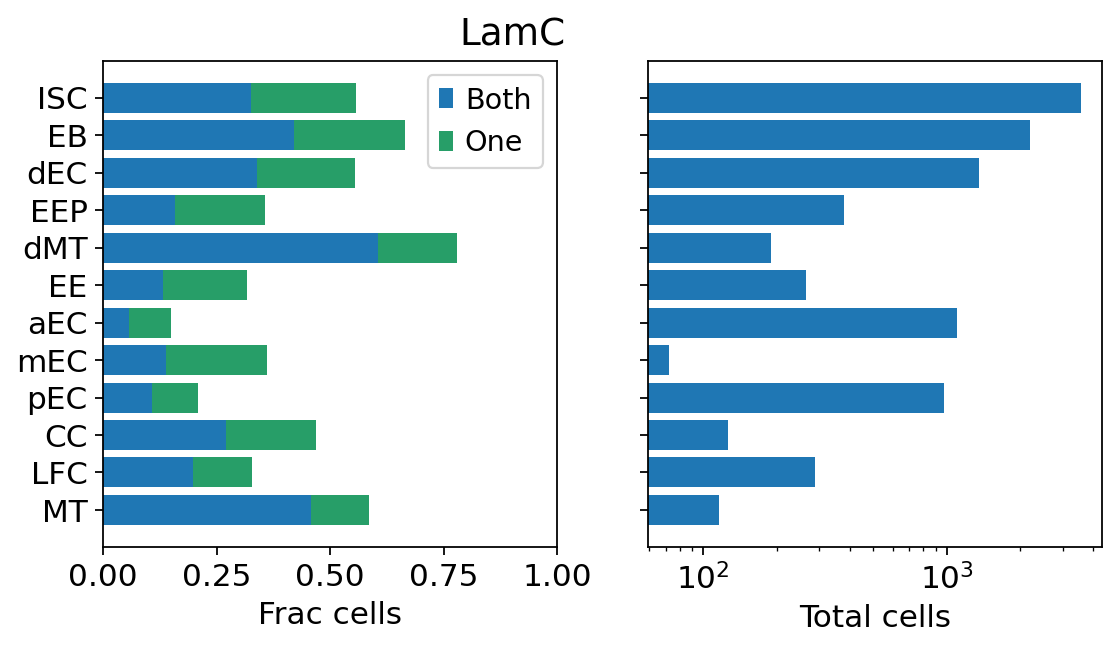

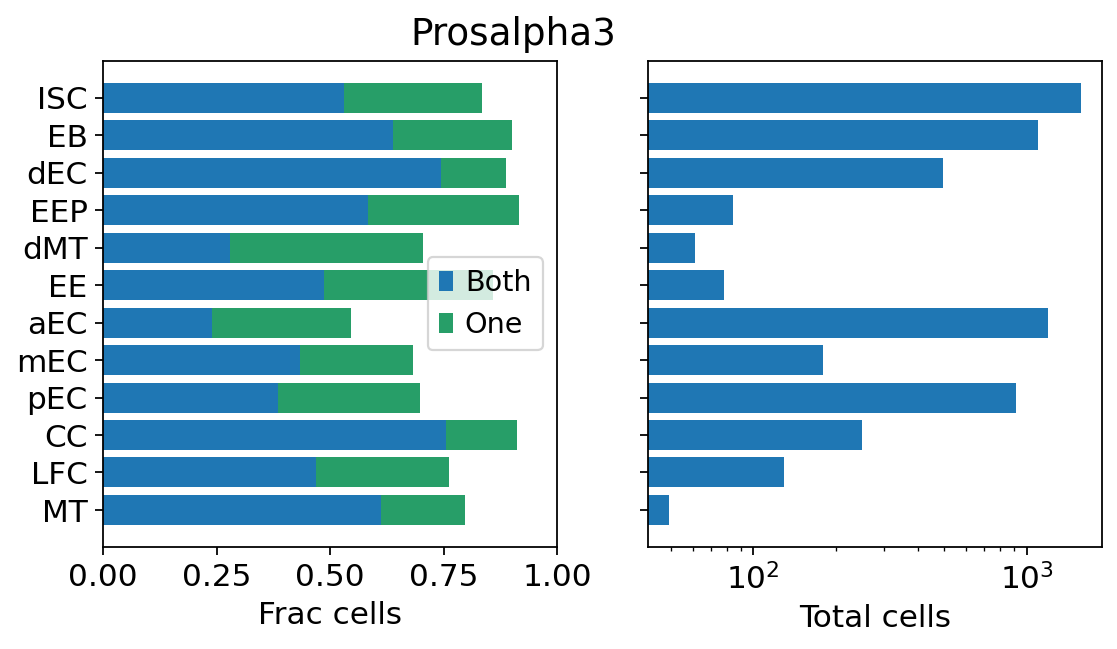

In [12]:
celltypes = ['ISC', 'EB', 'dEC', 'EEP', 'dMT', 'EE', 'aEC', 'mEC', 'pEC', 'CC', 'LFC', 'MT']
for goi in gois:
    print(goi)
    ct_totals, ct_frac1, ct_frac2, ct_called1, ct_called2 = [], [], [], [], []
    for ct in celltypes:
        tmp = bc_adata[np.logical_and(bc_adata.obs.perturbation == goi, bc_adata.obs.celltype == ct)]
        stats = Counter()
        for s in tmp.obs.het_hom_with_uncalled_status:
            stats['total'] += 1
            if s == 'uncalled':
                stats['1 called'] += 1
            elif s != '':
                stats['2 called'] += 1
        ct_totals.append(stats['total'])
        ct_called1.append(stats['1 called'])
        ct_called2.append(stats['2 called'])
        ct_frac1.append(stats['1 called']/stats['total'] if stats['total'] > 0 else 0)
        ct_frac2.append(stats['2 called']/stats['total'] if stats['total'] > 0 else 0)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    idxs = list(range(len(ct_totals)))
    axes[0].barh(idxs, ct_frac2, label='Both')
    axes[0].barh(idxs, ct_frac1, left=ct_frac2, color='C2', label='One')
    axes[1].barh(idxs, ct_totals)
    for ax in axes:
        ax.set_yticks(idxs)
        ax.set_ylim(ax.get_ylim()[::-1])
        ax.grid(False)
    axes[0].set_yticklabels(celltypes)
    axes[1].set_yticklabels([])
    axes[1].set_xscale('log')
    axes[0].set_xlabel('Frac cells')
    axes[1].set_xlabel('Total cells')
    axes[0].set_xlim((0, 1))
    axes[0].legend()
    fig.suptitle(goi)


## Top mutations and reproducibility

In [13]:
def get_mut_color(mut):
    if mut.startswith('D'):
        return 'salmon' #'Deletion'
    elif mut.startswith('I'):
        return 'goldenrod' #'Insertion'
    elif mut[0] in {'A', 'C', 'G', 'T'}:
        return 'b' #'Substitution'
    elif mut.startswith('J'):
        if mut.endswith('-'):
            return 'darkgreen' # 'Intron Retention'
        else:
            return 'darkviolet' #'Splice Change'
    else:
        return 'grey'

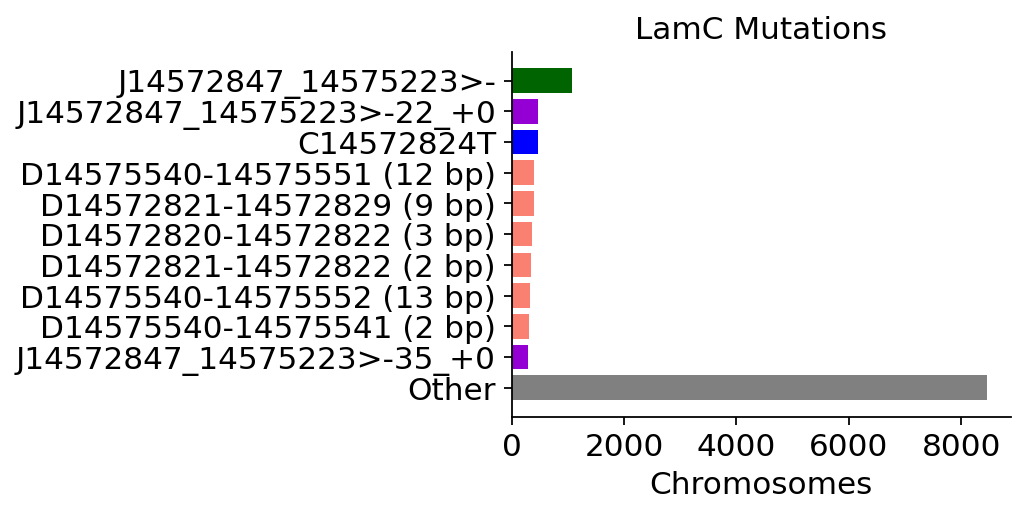

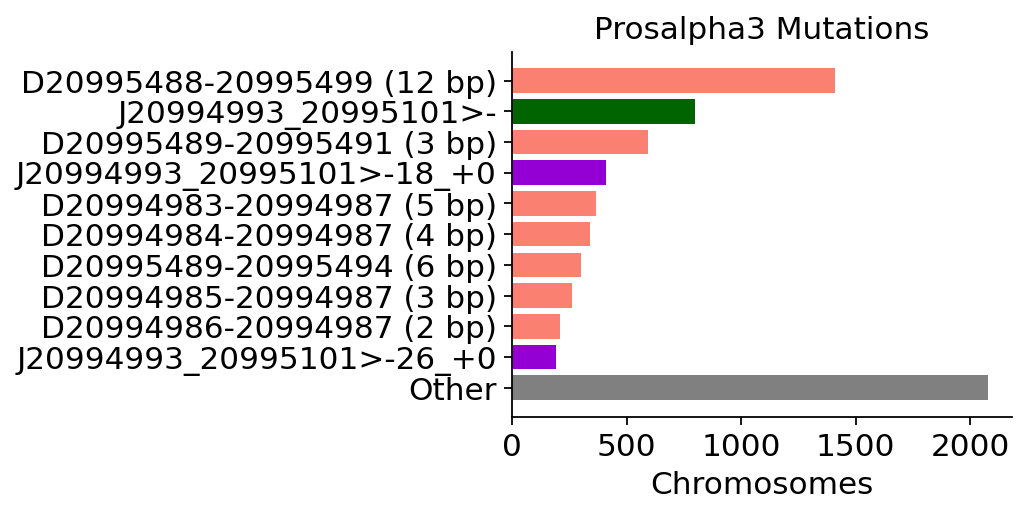

In [14]:
for goi in gois:
    perturbation_clone_ids = [ci for ci in bc_adata.obs['clone_id'] if '/' in ci and goi in ci]
    perturbation_clone_ids[:5]
    tx45_ids = [ci.split()[-1] for ci in perturbation_clone_ids if ci.split()[0] == 'TX45' and goi in ci]
    tx46_ids = [ci.split()[-1] for ci in perturbation_clone_ids if ci.split()[0] == 'TX46' and goi in ci]
    all_clone_ids = [ci.split()[-1] for ci in perturbation_clone_ids]
    
    top_n = 10
    title = f'{goi} Mutations'
    id_list = all_clone_ids
    mut_list = list(sorted(set([mut for clone_id in id_list for hap in clone_id.split('/') for mut in hap.split(',') if mut != 'wt'])))
    counts = [sum(1 for clone_id in id_list for hap in clone_id.split('/') if mut in hap) for mut in mut_list]
    mut_cntr = Counter({mut: count for mut, count in zip(mut_list, counts)})

    mc = mut_cntr.most_common()
    top_counts = [tup[1] for tup in mc[:top_n]]
    rest_count = sum(tup[1] for tup in mc[top_n:])
    top_names = []
    for tup in mc[:top_n]:
        mut = tup[0]
        if mut.startswith('D'):
            idx = mut.index('-')
            start, end = int(mut[1:idx]), int(mut[idx+1:])
            top_names.append(f'{mut} ({end - start + 1:d} bp)')
        else:
            top_names.append(mut)
        
    top_counts.append(rest_count)
    top_names.append('Other')
    top_colors = list(map(get_mut_color, top_names))

    fig, ax = plt.subplots(figsize=(4, 3))
    for color in set(top_colors):
        idx = [i for i, c in enumerate(top_colors) if color == c]
        vals = [c for i, c in enumerate(top_counts) if i in idx]
        ax.barh(idx, vals, color=color)
    ax.set_yticks(range(len(top_counts)))
    ax.set_yticklabels(top_names)
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.set_xlabel('Chromosomes')
    ax.set_title(title)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


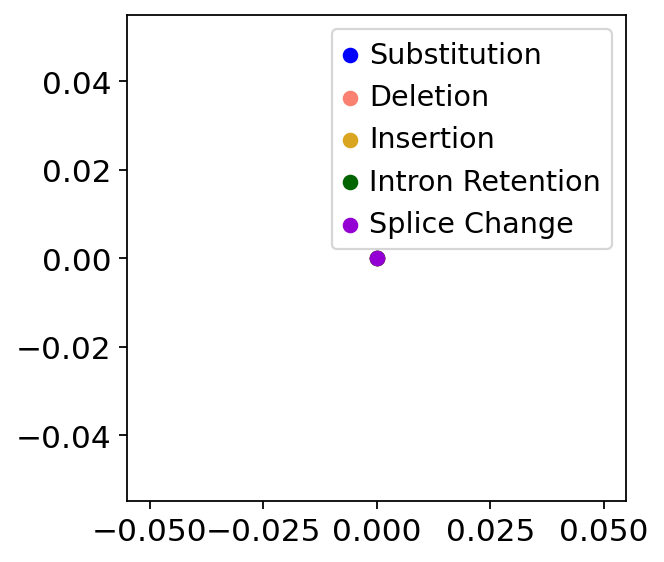

In [15]:
fig, ax = plt.subplots()
x, y = [0], [0]
ax.scatter(x, y, c='b', label='Substitution')
ax.scatter(x, y, c='salmon', label='Deletion')
ax.scatter(x, y, c='goldenrod', label='Insertion')
ax.scatter(x, y, c='darkgreen', label='Intron Retention')
ax.scatter(x, y, c='darkviolet', label='Splice Change')
ax.legend()
ax.grid(False)

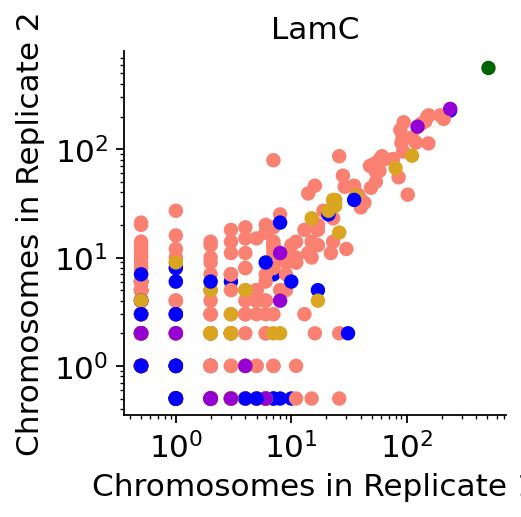

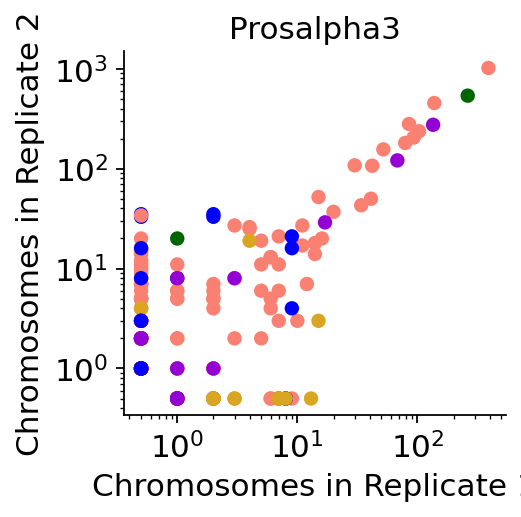

In [16]:
for goi in gois:
    perturbation_clone_ids = [ci for ci in bc_adata.obs['clone_id'] if '/' in ci and goi in ci]
    perturbation_clone_ids[:5]
    tx45_ids = [ci.split()[-1] for ci in perturbation_clone_ids if ci.split()[0] == 'TX45' and goi in ci]
    tx46_ids = [ci.split()[-1] for ci in perturbation_clone_ids if ci.split()[0] == 'TX46' and goi in ci]
    all_clone_ids = [ci.split()[-1] for ci in perturbation_clone_ids]
    
    mut_list = list(sorted(set([mut for clone_id in all_clone_ids for hap in clone_id.split('/') for mut in hap.split(',') if mut != 'wt'])))
    tx45_counts = [sum(1 for clone_id in tx45_ids for hap in clone_id.split('/') if mut in hap) for mut in mut_list]
    tx46_counts = [sum(1 for clone_id in tx46_ids for hap in clone_id.split('/') if mut in hap) for mut in mut_list]
    tx45_adj = np.array([c if c > 0 else 0.5 for c in tx45_counts])
    tx46_adj = np.array([c if c > 0 else 0.5 for c in tx46_counts])
    
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    ax.scatter(tx45_adj, tx46_adj, s=30, c=[get_mut_color(m) for m in mut_list])
    ax.grid(False)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Chromosomes in Replicate 1')
    ax.set_ylabel('Chromosomes in Replicate 2')
    ax.set_title(f'{goi}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

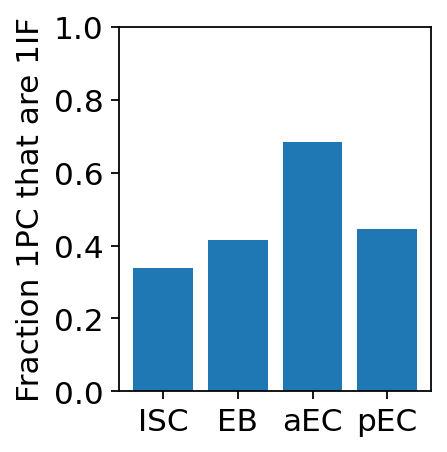

In [17]:
vals = []
celltypes = ['ISC', 'EB', 'aEC', 'pEC']
for ct in celltypes:
    tmp = bc_adata[np.logical_and(np.logical_and(bc_adata.obs.perturbation == 'Prosalpha3', bc_adata.obs.het_hom_status == 'het'), bc_adata.obs.celltype == ct)]
    cntr = Counter(tmp.obs.wtlike_status)
    vals.append(float(cntr['wt-like'])/sum(cntr.values()))

fig, ax = plt.subplots(figsize=(2.5, 3))
ax.bar(range(len(vals)), vals)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(celltypes)
ax.set_ylim((0, 1))
ax.set_ylabel('Fraction 1PC that are 1IF')
ax.grid(False)


### Mutation by celltypes

In [18]:
mut_cntr_given_pert_given_celltype = {goi: defaultdict(Counter) for goi in gois}
for run_label in run_labels:
    if 'ctrl' in run_label:
        continue
    rep, pert = run_label.split()
    tmp = bc_adata[bc_adata.obs.batch == run_label]
    for bc, ct, mut_sig in zip(tmp.obs.index, tmp.obs.celltype, tmp.obs.mut_sig_with_uncalled):
        bc = bc[:bc.index('-')] + '-1'
        if not mut_sig:
            continue
        mat_pat_muts = mut_sig.split('/')
        if mat_pat_muts == ['wt', 'wt']:
            stat = 'wt'
        elif set(mat_pat_muts) == set(['uncalled', 'wt']):
            stat = 'wt and missing'
        elif 'uncalled' in mat_pat_muts:
            assert mat_pat_muts.count('uncalled') == 1, mat_pat_muts
            stat = 'PC and missing'
        elif 'wt' in mat_pat_muts:
            stat = '1PC'
        else:
            stat = '2PC'
            
        mut_cntr_given_pert_given_celltype[pert][ct][stat] += 1

LamC % missing: 41.4%
Prosalpha3 % missing: 36.0%


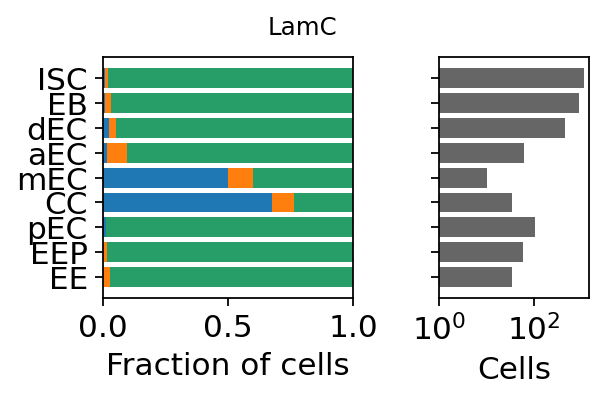

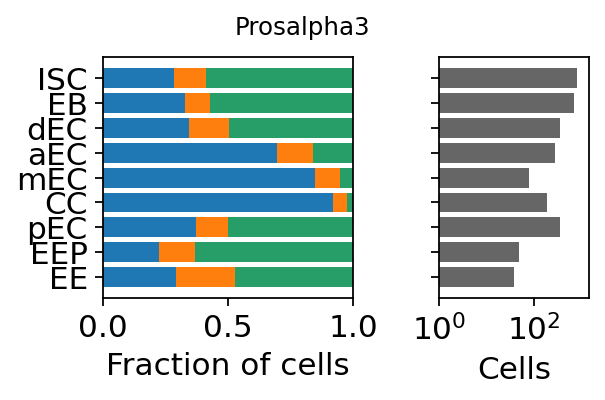

In [19]:
loc_celltypes = ['ISC', 'EB', 'dEC', 'aEC', 'mEC', 'CC', 'pEC', 'EEP', 'EE']
stats = ['wt', '1PC', '2PC', 'wt and missing', 'PC and missing']

for goi in gois:
    A = np.zeros((len(loc_celltypes), len(stats)), dtype=np.float64)
    for i, ct in enumerate(loc_celltypes):
        A[i, :] = [mut_cntr_given_pert_given_celltype[goi][ct][stat] for stat in stats]

    frac_missing = A[:, 3:].sum() / A.sum()
    print(f'{goi} % missing: {100*frac_missing:.1f}%')


    M = A[:, :3]
    totals = M.sum(axis=1)
    M = M / totals[:, None]
    
    fig, axes = plt.subplots(1, 2, figsize=(4, 2.5), gridspec_kw={'width_ratios': [5, 3]})
    ax = axes[0]
    start = np.zeros((len(loc_celltypes),))
    for j, stat in enumerate(stats[:3]):
        ax.barh(range(len(loc_celltypes)), M[:, j], left=start, label=stat)
        start += M[:, j]
    ax.grid(False)
    ax.set_xlabel('Fraction of cells')
    ax.set_yticks(range(len(loc_celltypes)))
    ax.set_yticklabels(loc_celltypes)
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.set_xlim([0, 1])
    ax.set_xticks([0, 0.5, 1])

    ax = axes[1]
    ax.grid(False)
    start = np.ones((len(loc_celltypes),))
    for M, c, label in [
        (A[:, :3], 0.4*np.ones((3,)), 'Both found'), 
    ]: 
        totals = M.sum(axis=1)
        totals_m1 = totals-1
        ax.barh(range(len(loc_celltypes)), totals_m1, left=start, color=c, label=label)
        start += totals
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.set_yticks(range(len(loc_celltypes)))
    ax.set_yticklabels([])
    ax.set_xlabel('Cells')
    ax.set_xscale('log')
    ax.set_xlim([1, 1.5e3])

    fig.tight_layout()
    fig.suptitle(goi, y=1.02, fontsize=11)



LamC % missing: 41.4%
Prosalpha3 % missing: 36.0%


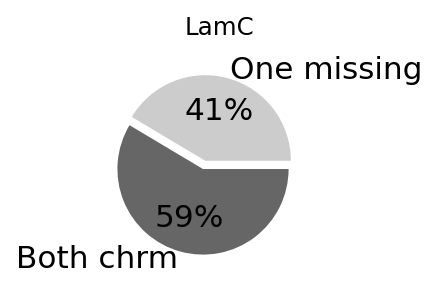

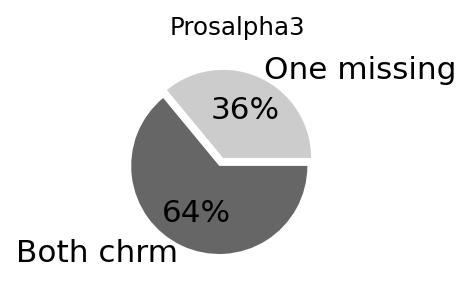

In [20]:
loc_celltypes = ['ISC', 'EB', 'dEC', 'aEC', 'mEC', 'CC', 'pEC', 'EEP', 'EE']
stats = ['wt', '1PC', '2PC', 'wt and missing', 'PC and missing']

for goi in gois:
    A = np.zeros((len(loc_celltypes), len(stats)), dtype=np.float64)
    for i, ct in enumerate(loc_celltypes):
        A[i, :] = [mut_cntr_given_pert_given_celltype[goi][ct][stat] for stat in stats]

    frac_missing = A[:, 3:].sum() / A.sum()
    print(f'{goi} % missing: {100*frac_missing:.1f}%')

    M = A[:, :3]
    totals = M.sum(axis=1)
    M = M / totals[:, None]
    
    fig, ax = plt.subplots(figsize=(3, 1.8))
    ax.pie([frac_missing, 1-frac_missing], labels=['One missing', 'Both chrm'], colors=[0.8*np.ones((3,)), 0.4*np.ones((3,))], autopct='%1.0f%%', explode=[0.1, 0])
    
    fig.tight_layout()
    fig.suptitle(goi, y=1.02, fontsize=11)

# Clone analysis

/scratch/jobs/50207895/ipykernel_2075343/3415227437.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(tmp.obsm['X_umap'][i, 0], tmp.obsm['X_umap'][i, 1], color=celltype_colors[tmp.obs.celltype[i]], s=20, zorder=1000)
/scratch/jobs/50207895/ipykernel_2075343/3415227437.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(tmp.obsm['X_umap'][[i, j], 0], tmp.obsm['X_umap'][[i, j], 1], color=celltype_colors[tmp.obs.celltype[0]], lw=1, alpha=0.8, zorder=10)
/scratch/jobs/50207895/ipykernel_2075343/3415227437.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future

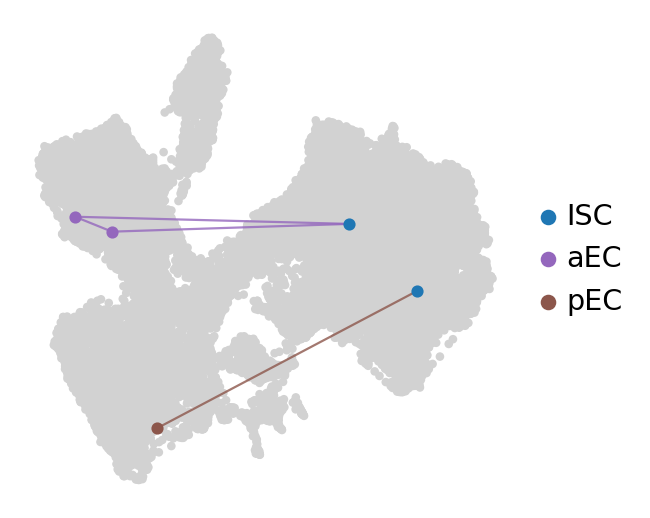

In [21]:
loc_clone_ids = {
    'TX45 Prosalpha3 D20994983-20994987,D20995488-20995499/D20994980-20994987,D20995488-20995544': 'pEC',  
    'TX46 Prosalpha3 J20994993_20995101>-18_+0,D20995489-20995494/D20994985-20994987,D20995490-20995501': 'aEC',
}
celltype_colors = {ct: color for ct, color in zip(bc_adata.obs.celltype.cat.categories, bc_adata.uns['celltype_colors'])}
tmp = bc_adata.copy()
clust = 'examples'
vals = [loc_clone_ids[ci] if ci in loc_clone_ids else '' for ci in tmp.obs.clone_id]
vals[0] = 'ISC'
tmp.obs[clust] = vals
tmp.obs[clust] = tmp.obs[clust].astype('category')
tmp.uns[clust+'_colors'] = ['#d2d2d2', celltype_colors['ISC'], celltype_colors['aEC'], celltype_colors['pEC']]
fig = sc.pl.umap(tmp, color='examples', size=60, sort_order=False, zorder=-11, return_fig=True, frameon=False, title='')
ax = fig.axes[0]
for ci, region in loc_clone_ids.items():
    tmp = bc_adata[bc_adata.obs.clone_id == ci]
    for i in range(len(tmp)):
        ax.scatter(tmp.obsm['X_umap'][i, 0], tmp.obsm['X_umap'][i, 1], color=celltype_colors[tmp.obs.celltype[i]], s=20, zorder=1000)
        
    for i, j in itertools.combinations(range(len(tmp)), 2):
        if region == 'pEC':
            ax.plot(tmp.obsm['X_umap'][[i, j], 0], tmp.obsm['X_umap'][[i, j], 1], color=celltype_colors[tmp.obs.celltype[0]], lw=1, alpha=0.8, zorder=10)
        else:
            ax.plot(tmp.obsm['X_umap'][[i, j], 0], tmp.obsm['X_umap'][[i, j], 1], color=celltype_colors[tmp.obs.celltype[1]], lw=1, alpha=0.8, zorder=10)

In [ ]:
fg_dotsize=100
tmp = bc_adata[bc_adata.obs.unique_clone]
sc.tl.embedding_density(tmp, basis='umap', groupby='clone_aEC_pEC')
fig = sc.pl.embedding_density(tmp, basis='umap', groupby='clone_aEC_pEC', group='pEC', fg_dotsize=fg_dotsize, frameon=False, title='pEC', return_fig=True)
fig = sc.pl.embedding_density(tmp, basis='umap', groupby='clone_aEC_pEC', group='aEC', fg_dotsize=fg_dotsize, frameon=False, title='aEC', return_fig=True)

computing density on 'umap'
--> added
    'umap_density_clone_aEC_pEC', densities (adata.obs)
    'umap_density_clone_aEC_pEC_params', parameter (adata.uns)


/home/hawkins/venvs/envsinglecell/lib/python3.11/site-packages/scanpy/tools/_embedding_density.py:179: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[density_covariate] = density_values


In [ ]:
fg_dotsize=100
overall_cntr = Counter()
for group in ['pEC', 'aEC']:
    tmp = bc_adata[np.logical_and(bc_adata.obs.unique_clone, bc_adata.obs.clone_aEC_pEC == group)]
    cntr = Counter(tmp.obs.clone_id)
    print(f'{group[-3:]}')
    print(f'  Number of clones: {len(cntr)}')
    print(f'  Number of cells: {sum(cntr.values()):,d}')
    print(f'  Average clone size: {np.mean(list(cntr.values()))}')
    print(f'  Median clone size: {np.median(list(cntr.values()))}')
    overall_cntr.update(cntr)

cntr = overall_cntr
print('Overall')
print(f'  Number of clones: {len(cntr)}')
print(f'  Number of cells: {sum(cntr.values()):,d}')
print(f'  Average clone size: {np.mean(list(cntr.values()))}')
print(f'  Median clone size: {np.median(list(cntr.values()))}')
fig, ax = plt.subplots()
ax.hist(cntr.values(), 20)
ax.set_xlabel('Cells per clone')
ax.set_ylabel('Count')
xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(0.75*xlim[1], 0.75*ylim[1], f'Clones: {len(cntr)}\nCells: {sum(cntr.values())}', ha='center')
ax.grid(False)

In [ ]:
fg_dotsize=100
for goi in gois:
    tmp = bc_adata[bc_adata.obs.perturbation == goi]
    tmp = tmp[tmp.obs.unique_clone]
    sc.tl.embedding_density(tmp, basis='umap', groupby='clone_aEC_pEC')
    fig = sc.pl.embedding_density(tmp, basis='umap', groupby='clone_aEC_pEC', group='pEC', fg_dotsize=fg_dotsize, frameon=False, title=f'{goi} pEC', return_fig=True)
    fig = sc.pl.embedding_density(tmp, basis='umap', groupby='clone_aEC_pEC', group='aEC', fg_dotsize=fg_dotsize, frameon=False, title=f'{goi} aEC', return_fig=True)

In [ ]:
vals_given_apEC_label = {}
annotation = defaultdict(set)
for ct, clust in zip(bc_adata.obs.celltype, bc_adata.obs.leiden):
    annotation[ct].add(int(clust))
clusts = list(map(str, sorted(annotation['ISC'])))
apEC_labels = ['aEC', 'pEC']
for apEC_label in apEC_labels:
    vals = []
    for clust in clusts:
        tmp = bc_adata[bc_adata.obs['leiden'].isin([clust]),:]
        vals.append(sum(1 for v in tmp.obs.clone_aEC_pEC if v == apEC_label)/len(tmp))
    vals_given_apEC_label[apEC_label] = np.array(vals)

    fig, ax = plt.subplots(figsize=(3.5, 1.5))
    idx = list(range(len(clusts)))
    ax.bar(idx, vals)
    ax.set_xlabel('Leiden cluster')
    ax.set_ylabel(f'Frac cells')
    ax.set_xticks(idx)
    ax.set_xticklabels(clusts, rotation=90)
    ax.set_title(f'ISC cells connected to {apEC_label[-3:]}')
    ax.grid(False)
    ax.set_xlim((-1, max(idx)+1))

In [ ]:
def cluster_small_multiples(adata, clust_key, size=60, frameon=False, legend_loc=None, categories=None, color=None, **kwargs):
    tmp = adata.copy()

    if categories is None:
        categories = adata.obs[clust_key].cat.categories
    set_color = True if color is None else False
    for i,clust in enumerate(categories):
        if set_color:
            color = adata.uns[clust_key+'_colors'][i]
        tmp.obs[clust] = adata.obs[clust_key].isin([clust]).astype('category')
        tmp.uns[clust+'_colors'] = ['#d2d2d2', color]

    sc.pl.umap(tmp, groups=tmp.obs[clust].cat.categories[1:].values, color=categories, size=size, frameon=frameon, legend_loc=legend_loc, **kwargs)

In [ ]:
cluster_small_multiples(bc_adata, 'leiden', categories=['7', '25'])

# Dosage

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3), gridspec_kw=dict(wspace=0.1))
loc_statuses = ['wt', 'het', 'hom']
for ax_idx, (ax, ct) in enumerate(zip(axes.flatten(), ['ISC', 'EB', 'aEC', 'pEC', 'mEC', 'CC', 'LFC', 'EE'])):
    if ax_idx >= 4:
        break
    genes = [f'Prosalpha{i}' for i in range(2, 8)] + [f'Prosbeta{i}' for i in range(1, 8)] #+ ['Rpt3R']
    genes = [gene for gene in genes if gene in bc_adata.raw.var.index and gene != 'Prosalpha3']
    series = []
    cell_counts = []
    for gene in genes:
        gene_series = []
        cc = []
        for status in loc_statuses:
            tmp = bc_adata[np.logical_and(np.logical_and(bc_adata.obs.perturbation == 'Prosalpha3', bc_adata.obs.wtlike_status == status), bc_adata.obs.celltype == ct)].raw
            tmp = tmp[:, [gene]]
            n = tmp.X.shape[0]
            cc.append(n)
            if n:
                gene_series.append(tmp.X.mean())
            else:
                gene_series.append(np.nan)
        series.append(gene_series)
        cell_counts.append(cc)
    
    data = [[run[i] for run in series] for i in range(len(loc_statuses))]
    ax.violinplot(data, showmeans=True)
    for i, vals in enumerate(data):
        if i+1 < len(data):
            ax.plot([i+1.1, i+1.9], [0.2]*2, 'k')
            other_vals = data[i+1]
            res = ttest_ind(vals, other_vals)
            if res.pvalue < 0.001:
                t = '***'
            elif res.pvalue < 0.01:
                t = '**'
            elif res.pvalue < 0.05:
                t = '*'
            else:
                t = 'ns'
            ax.text(i+1.5, 0.15, t, ha='center', va='top')
            
    ax.set_xticks(range(1, len(loc_statuses)+1))
    ax.set_xticklabels(['wt', '1FS', '2FS'], rotation=90)
    if ax_idx == 0:
        ax.set_ylabel('Proteosome Core Expression')
    ax.set_xlim((0, len(loc_statuses)+1))
    ax.grid(False)
    ax.set_title(f'{ct}')

ymax = max(ax.get_ylim()[1] for ax in axes.flatten())
for i, ax in enumerate(axes.flatten()):
    ax.set_ylim((0, ymax))
    ax.set_yticks([yy for yy in np.arange(20)/2 if yy < ax.get_ylim()[1]])
    if i > 0:
        ax.set_yticklabels([])
print()


In [ ]:
# Apoptosis genes
genes = [
    'rpr', # reaper (rpr) Trigger caspase activation
    'Dronc', # Activates downstream effectors
    'Dcp-1', 'Drice', 'Decay', # Execute apoptosis
    'Dark', # Assembles apoptosome for caspase activation
    'Diap1', # Blocks caspase activation
    'mrn', 'tefu', 'mei-41', # (tefu=ATM, mei-41=ATR) Detect genotoxic stress
    'p53', 'bsk', # (bsk=JNK) Amplify apoptotic signaling
    'Atg3', 'SNF4Aγ', 'bchs', # (Atg3=Aut1) Modulate Dcp-1 induced apoptosis
    'grim', 'hid', # induces apoptosis
    'Cdk5α', # (Cdk5α=p35) inhibits apoptosis
]
genes = [gene for gene in genes if gene in bc_adata.raw.var.index and gene != 'Prosalpha3']
celltypes = ['ISC', 'EB', 'aEC', 'pEC'] #, 'mEC', 'CC', 'dEC', 'EE']
fig, axes = plt.subplots(int(np.ceil(len(celltypes)/4.0)), min(4, len(celltypes)), figsize=(16, 5*int(np.ceil(len(celltypes)/4.0))), gridspec_kw=dict(hspace=0.1))
for ax, ct in zip(axes.flatten(), celltypes):
    het_hom_statuses = ['wt', 'het', 'hom']
    series = []
    cell_counts = []
    for gene in genes:
        gene_series = []
        cc = []
        for status in het_hom_statuses:
            tmp = bc_adata[np.logical_and(np.logical_and(bc_adata.obs.perturbation == 'Prosalpha3', bc_adata.obs.het_hom_status == status), bc_adata.obs.celltype == ct)].raw
            tmp = tmp[:, [gene]]
            cc.append(tmp.X.shape[0])
            gene_series.append(tmp.X.mean())
        series.append(gene_series)
        cell_counts.append(cc)
    
    for gene_series, gene, cc in zip(series, genes, cell_counts):
        ax.plot(range(3), gene_series, label=gene)
    ax.set_xticks(range(3))
    ax.set_xticklabels(['wt', '1PC', '2PC'])
    if ax == axes[0]:
        ax.set_ylabel('Avg log1p Normalized Expression')
    else:
        ax.set_yticklabels([])
    ax.legend(fontsize=11)
    ax.set_xlim((-1, 5))
    ax.grid(False)
    ax.set_title(f'{ct}')

ymax = max(ax.get_ylim()[1] for ax in axes.flatten())
ymin = min(0, min(ax.get_ylim()[0] for ax in axes.flatten()))
for ax in axes.flatten():
    ax.set_ylim((ymin, ymax))
    ax.set_yticks([yy for yy in np.arange(20)/2 if yy < ax.get_ylim()[1]])

print()